# 🧹 Notebook 2 — Pipeline 1: Data Processing

**Objetivo:** Reproducir y entender paso a paso lo que hace el Pipeline 1 de Kedro  
**Input:** `data/01_raw/Attributes.csv`  
**Output:** `data/02_intermediate/clean_attributes.csv`

---
### ¿Qué hace este pipeline?
1. Eliminar columnas no útiles (`image_id`)
2. Detectar y eliminar duplicados
3. Verificar valores nulos
4. Validar que todos los valores sean binarios (0 o 1)
5. Generar estadísticas descriptivas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings = __import__('warnings'); warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## Paso 1 — Cargar el dataset crudo

In [2]:
df_raw = pd.read_csv('../data/01_raw/Attributes.csv')
print(f'Dataset crudo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head(3)

Dataset crudo: 30,141 filas × 34 columnas
Columnas: ['image_id', 'attractive', 'blurry_image', 'sharp_jawline', 'high_cheekbones', 'smiling', 'bald', 'receeding_hairline', 'long_hair', 'curly_hair', 'grey_hair', 'black_hair', 'has_beard', 'patchy_beard', 'has_mustache', 'well_groomed', 'has_makeup', 'wearing_glasses', 'wearing_hat', 'clear_skin', 'dark_circles', 'oily_skin', 'thick_eyebrow', 'big_eyes', 'big_lips', 'sharp_nose', 'adult', 'old', 'mouth_open', 'male', 'double_chin', 'veil', 'wrinkle', 'chubby']


,image_id,attractive,blurry_image,sharp_jawline,high_cheekbones,smiling,bald,receeding_hairline,long_hair,curly_hair,...,big_lips,sharp_nose,adult,old,mouth_open,male,double_chin,veil,wrinkle,chubby
0,00001.jpg,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,1,0,0,1,1
1,00002.jpg,1,0,0,1,1,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
2,00003.jpg,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0


## Paso 2 — Eliminar columnas no útiles

In [3]:
# image_id es solo un nombre de archivo (ej: 00001.jpg), no sirve como feature
df = df_raw.drop(columns=['image_id'])
print(f'Columnas eliminadas: [image_id]')
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Columnas eliminadas: [image_id]
Dataset: 30,141 filas × 33 columnas


,attractive,blurry_image,sharp_jawline,high_cheekbones,smiling,bald,receeding_hairline,long_hair,curly_hair,grey_hair,...,big_lips,sharp_nose,adult,old,mouth_open,male,double_chin,veil,wrinkle,chubby
0,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,1
1,1,0,0,1,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0


## Paso 3 — Detectar y eliminar duplicados

In [4]:
n_duplicados = df.duplicated().sum()
print(f'Filas totales antes:      {len(df):,}')
print(f'Filas duplicadas:         {n_duplicados:,}')
print(f'Porcentaje de duplicados: {n_duplicados/len(df)*100:.1f}%')

df = df.drop_duplicates()
print(f'\nFilas después de limpiar: {len(df):,}')
print(f'✅ Duplicados eliminados correctamente')

Filas totales antes:      30,141
Filas duplicadas:         17,000
Porcentaje de duplicados: 56.4%

Filas después de limpiar: 13,141
✅ Duplicados eliminados correctamente


## Paso 4 — Verificar valores nulos

In [5]:
nulos = df.isnull().sum()
print('Valores nulos por columna:')
if nulos.sum() == 0:
    print('✅ No hay valores nulos en el dataset')
else:
    print(nulos[nulos > 0])
    df = df.dropna()
    print(f'\nFilas después de eliminar nulos: {len(df):,}')

Valores nulos por columna:
✅ No hay valores nulos en el dataset


## Paso 5 — Validar que los valores son binarios (0 o 1)

In [7]:
print('Validación de valores binarios:')
problemas = []
for col in df.columns:
    valores = set(df[col].unique())
    if not valores.issubset({0, 1}):
        problemas.append(f'  ⚠️ {col}: {valores}')

if problemas:
    print('Columnas con valores no binarios:')
    for p in problemas: print(p)
else:
    print(f'✅ Todas las {df.shape[1]} columnas tienen valores binarios (0 o 1)')

Validación de valores binarios:
✅ Todas las 33 columnas tienen valores binarios (0 o 1)


## Paso 6 — Estadísticas descriptivas del dataset limpio

In [8]:
# Tabla de estadísticas por atributo
stats = pd.DataFrame({
    'Total con atributo': df.sum().astype(int),
    'Porcentaje (%)': (df.mean() * 100).round(2),
    'Desv. Estándar': df.std().round(4)
}).sort_values('Porcentaje (%)', ascending=False)

print(f'Dataset limpio final: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print()
stats

Dataset limpio final: 13,141 filas × 33 columnas



,Total con atributo,Porcentaje (%),Desv. Estándar
adult,11544,87.85,0.3268
black_hair,9776,74.39,0.4365
male,9154,69.66,0.4597
clear_skin,8345,63.50,0.4814
well_groomed,7523,57.25,0.4947
thick_eyebrow,6568,49.98,0.5000
chubby,6391,48.63,0.4998
smiling,6190,47.10,0.4992
mouth_open,5275,40.14,0.4902
dark_circles,4972,37.84,0.4850


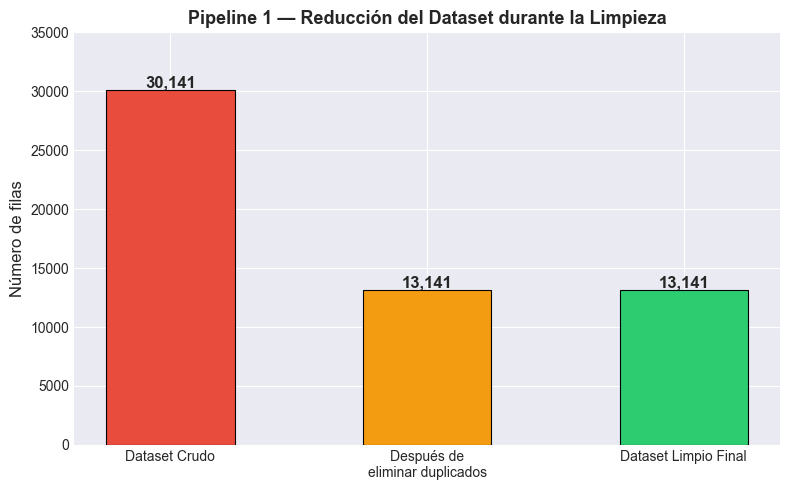


✅ Pipeline 1 completado
   Eliminamos 17,000 filas duplicadas (56.4% del dataset original)


In [9]:
# Comparación antes vs después de la limpieza
fig, ax = plt.subplots(figsize=(8, 5))
categorias = ['Dataset Crudo', 'Después de\neliminar duplicados', 'Dataset Limpio Final']
valores = [30141, 13141, 13141]
colores = ['#E74C3C', '#F39C12', '#2ECC71']
bars = ax.bar(categorias, valores, color=colores, edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Número de filas', fontsize=12)
ax.set_title('Pipeline 1 — Reducción del Dataset durante la Limpieza', fontsize=13, fontweight='bold')
ax.set_ylim(0, 35000)
plt.tight_layout()
plt.savefig('../data/08_reporting/limpieza_datos.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n✅ Pipeline 1 completado')
print(f'   Eliminamos {30141 - 13141:,} filas duplicadas ({(30141-13141)/30141*100:.1f}% del dataset original)')

## ✅ Resumen del Pipeline 1

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Eliminar `image_id` | De 34 → 33 columnas |
| 2 | Eliminar duplicados | De 30.141 → 13.141 filas |
| 3 | Verificar nulos | ✅ Sin nulos |
| 4 | Validar binarios | ✅ Todos son 0 o 1 |

El dataset limpio se guarda en `data/02_intermediate/clean_attributes.csv`